### 4.2 NMF Model

In [3]:
partis = df["parti"]
annees = df["year"] 


===== TOPICS =====
Administration locale maire | général | conseiller | union | centre | président | député | jean | conseil | homme
Extrême droite front | national | vote | rpr | udf | électeur | liste | conviction | suppression | votez
Gauche ouvrière travailleur | gauche | lutte | ouvrière | laguiller | mitterrand | arlette | falloir | chambre | envoyer
Économie & travail accepter | triage | illusion | sortir | europe | détruire | technologie | financier | production | grand
Pouvoir & finance communiste | changement | gauche | réussir | majorité | victoire | 14 | union | gouvernement | parti
Mobilisation électeurs entreprise | devoir | travail | développement | économique | droit | aide | pourcent | vie | familial
France unie & solidarité gauche | communiste | parti | milliard | alliance | rassemblement | franc | 000 | voix | surarmement
Écologie & énergie unie | michel | majorité | solidarité | rocard | françois | exclusion | égalité | mitterrand | uni
Union de la gauche patrie | 

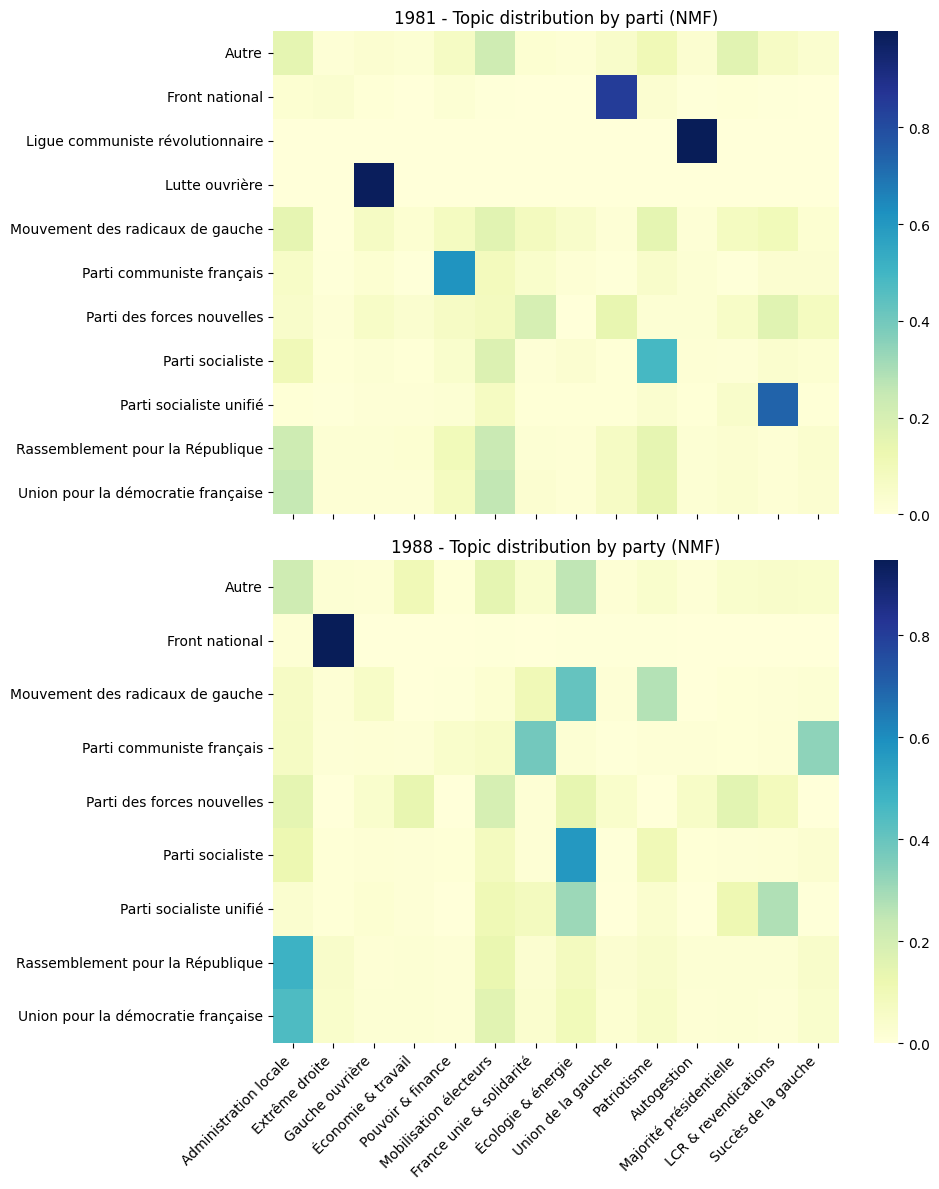

In [ ]:
n_topics = 14
ngram_range = (1, 1)

topic_titles = [
    "Administration locale",
    "Extrême droite",
    "Gauche ouvrière",                
    "Économie & travail",      
    "Pouvoir & finance",       
    "Mobilisation électeurs",
    "France unie & solidarité",     
    "Écologie & énergie",
    "Union de la gauche",           
    "Patriotisme",             
    "Autogestion",       
    "Majorité présidentielle",        
    "LCR & revendications",
    "Succès de la gauche" 
]

# =========================
# TF-IDF
# =========================
vectorizer = TfidfVectorizer(
    stop_words=STOPWORDS,
    ngram_range=ngram_range,
    min_df=0.005,
    max_df=0.7
)

X = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

# NMF
nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvd"
)

W = nmf_model.fit_transform(X)
W = W / W.sum(axis=1, keepdims=True)

# Print topics
def print_topics(model, feature_names, topk=10):
    for i, topic in enumerate(model.components_):
        top_words = [feature_names[j] for j in topic.argsort()[-topk:][::-1]]
        print(f"{topic_titles[i]} {' | '.join(top_words)}")

print("\n===== TOPICS =====")
print_topics(nmf_model, feature_names)

# DATAFRAME
df2 = pd.DataFrame(W, columns=[f"topic_{i}" for i in range(n_topics)])
df2["parti"] = partis
df2["annee"] = annees  # ⚠️ important : 1981 / 1988


topic_parti_annee = df2.groupby(["annee", "parti"]).mean()

topic_81 = topic_parti_annee.loc[1981]
topic_88 = topic_parti_annee.loc[1988]

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# 1981
sns.heatmap(topic_81, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("1981 - Topic distribution by parti (NMF)")
axes[0].set_ylabel(None)

# 1988
sns.heatmap(topic_88, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("1988 - Topic distribution by party (NMF)")
axes[1].set_ylabel(None)
axes[1].set_xticklabels(topic_titles, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("nmf_results.png",dpi=300)
plt.show()

In [22]:
topic_parti = df2.groupby("parti").mean()
topic_parti.drop(columns=["annee"], inplace=True)
topic_parti_annee = df2.groupby(["annee", "parti"]).mean().reset_index()

In [ ]:
pca = PCA(n_components=2)
coords = pca.fit_transform(topic_parti)

topic_parti_2d = pd.DataFrame(coords, columns=["Dim1", "Dim2"])
topic_parti_2d["parti"] = topic_parti.index

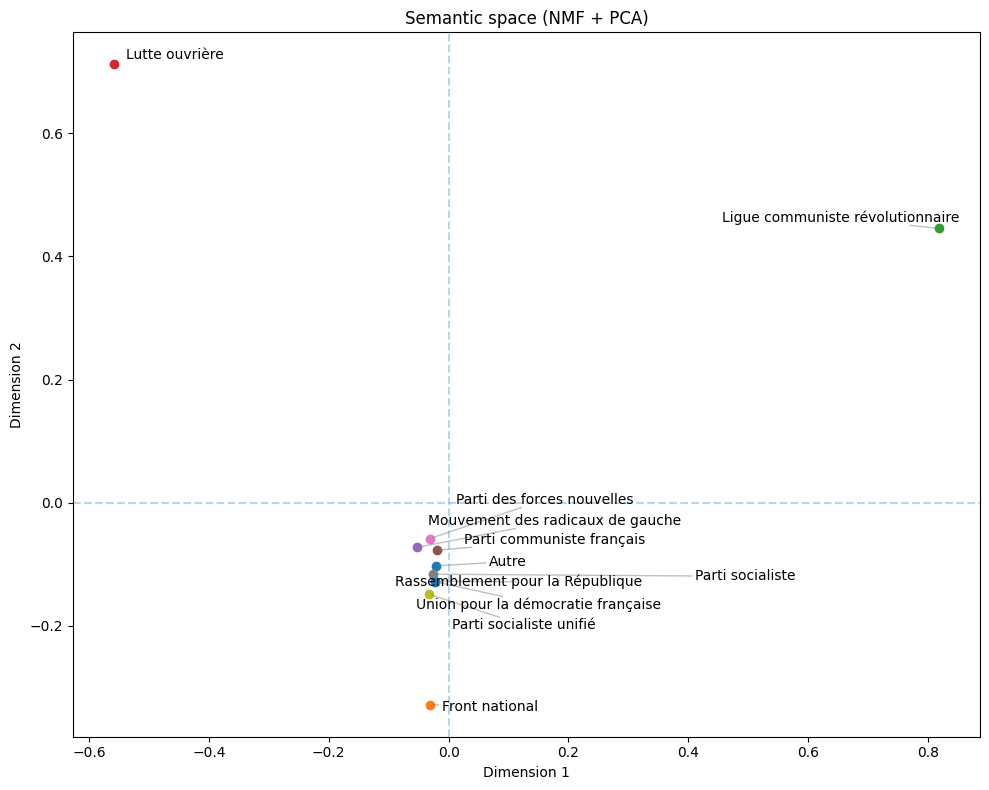

In [31]:
from adjustText import adjust_text

plt.figure(figsize=(10, 8))

texts = []

for _, row in topic_parti_2d.iterrows():
    plt.scatter(row["Dim1"], row["Dim2"])
    texts.append(
        plt.text(row["Dim1"], row["Dim2"], row["parti"])
    )

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', alpha=0.5))

plt.axhline(0, linestyle="--", alpha=0.3)
plt.axvline(0, linestyle="--", alpha=0.3)

plt.title("Semantic space (NMF + PCA)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.savefig("nmf_pca_projection.png", dpi=300)
plt.show()

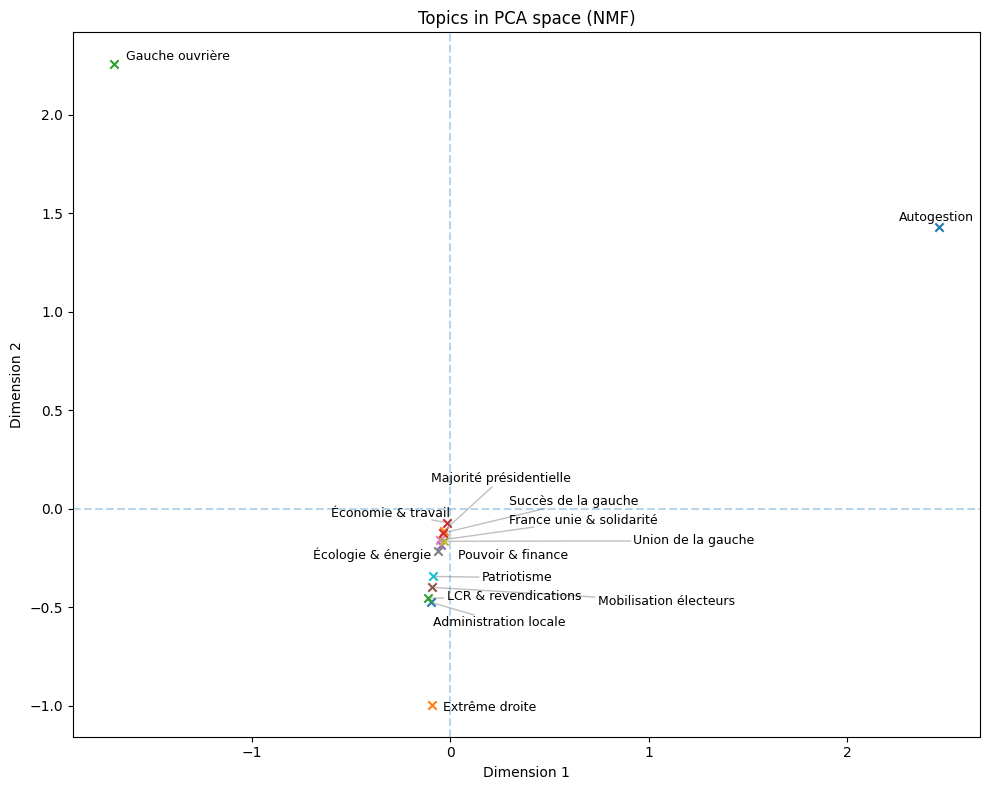

In [36]:
plt.figure(figsize=(10, 8))

texts = []

# =========================
# TOPICS ONLY
# =========================
scale = 3  # ajuste si nécessaire

for topic in topic_titles:
    x = loadings.loc["Dim1", topic] * scale
    y = loadings.loc["Dim2", topic] * scale
    
    plt.scatter(x, y, marker="x")
    
    texts.append(
        plt.text(x, y, topic, fontsize=9)
    )

# Ajustement des labels
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', alpha=0.5))

# Axes
plt.axhline(0, linestyle="--", alpha=0.3)
plt.axvline(0, linestyle="--", alpha=0.3)

plt.title("Topics in PCA space (NMF)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.savefig("nmf_topics_pca.png", dpi=300)
plt.show()

In [33]:
loadings = pd.DataFrame(
    pca.components_,
    columns=topic_titles,
    index=["Dim1", "Dim2"]
)

print(loadings.T.sort_values("Dim1", ascending=False))
print(loadings.T.sort_values("Dim2", ascending=False))

                              Dim1      Dim2
Autogestion               0.820866  0.476933
Économie & travail       -0.006117 -0.023177
Majorité présidentielle  -0.010388 -0.037185
Union de la gauche       -0.010694 -0.054938
Succès de la gauche      -0.011692 -0.040793
Pouvoir & finance        -0.015834 -0.060967
France unie & solidarité -0.017974 -0.053157
Écologie & énergie       -0.020829 -0.070541
Patriotisme              -0.029842 -0.114444
Mobilisation électeurs   -0.030833 -0.132933
Extrême droite           -0.031107 -0.331493
Administration locale    -0.033295 -0.158034
LCR & revendications     -0.037028 -0.151490
Gauche ouvrière          -0.565232  0.752219
                              Dim1      Dim2
Gauche ouvrière          -0.565232  0.752219
Autogestion               0.820866  0.476933
Économie & travail       -0.006117 -0.023177
Majorité présidentielle  -0.010388 -0.037185
Succès de la gauche      -0.011692 -0.040793
France unie & solidarité -0.017974 -0.053157
Union de l

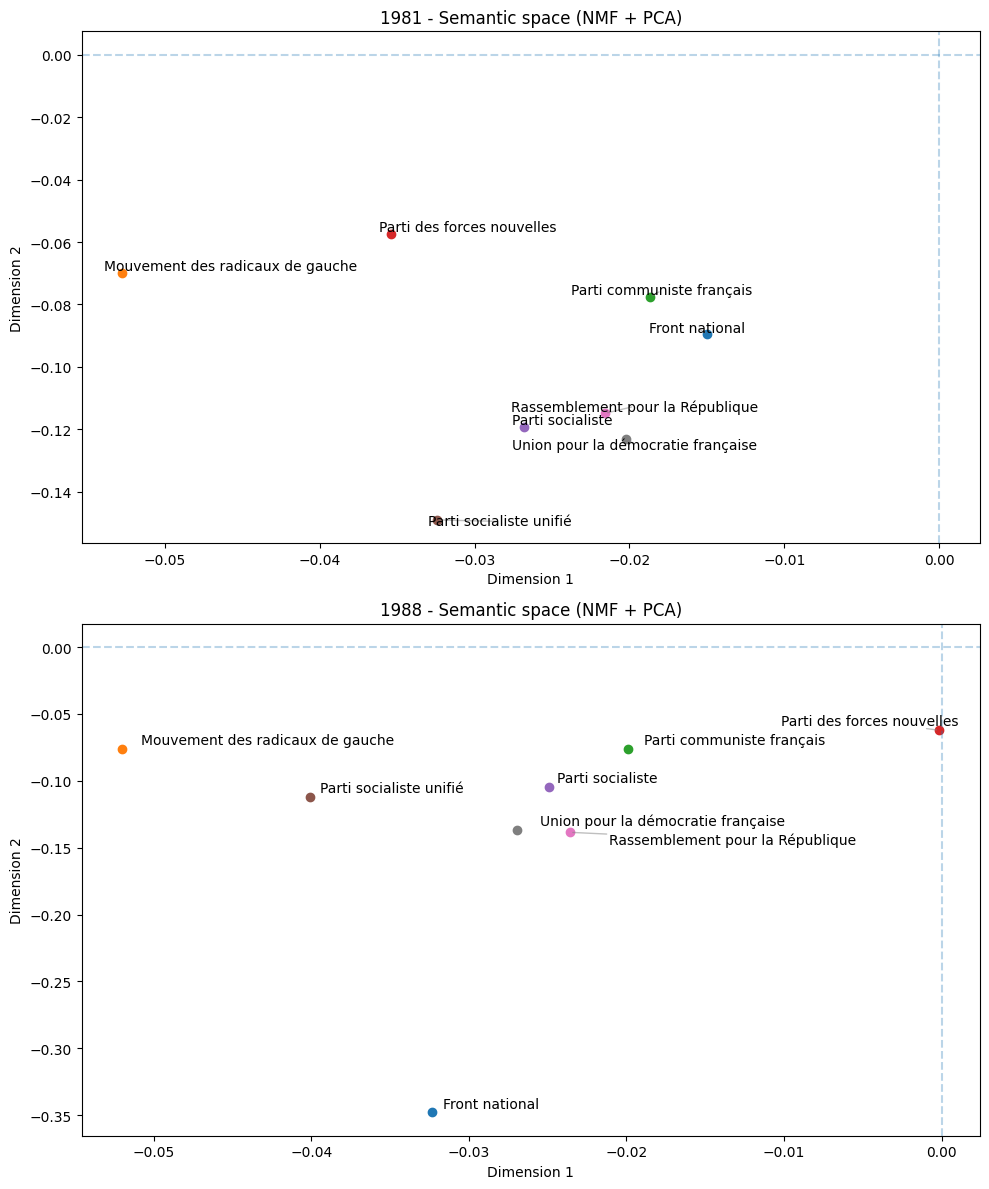

In [34]:
from sklearn.decomposition import PCA
from adjustText import adjust_text
import matplotlib.pyplot as plt

# =========================
# 1. PCA globale (sur tous les partis)
# =========================
topic_cols = [f"topic_{i}" for i in range(n_topics)]

topic_parti_global = df2.groupby("parti")[topic_cols].mean()

pca = PCA(n_components=2)
pca.fit(topic_parti_global)

# =========================
# 2. Fonction projection + plot
# =========================
def plot_year(year, ax):
    
    # Moyenne par parti pour l'année
    df_year = df2[df2["annee"] == year]
    topic_parti_year = df_year.groupby("parti")[topic_cols].mean()
    
    # Projection dans l'espace PCA global
    coords = pca.transform(topic_parti_year)
    
    topic_parti_2d = pd.DataFrame(coords, columns=["Dim1", "Dim2"])
    topic_parti_2d["parti"] = topic_parti_year.index
    
    # Exclusions
    topic_parti_2d = topic_parti_2d[
        ~topic_parti_2d["parti"].isin([
            "Lutte ouvrière",
            "Ligue communiste révolutionnaire",
            "Autre"
        ])
    ]
    
    # Plot
    texts = []
    
    for _, row in topic_parti_2d.iterrows():
        ax.scatter(row["Dim1"], row["Dim2"])
        texts.append(
            ax.text(row["Dim1"], row["Dim2"], row["parti"])
        )
    
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color='gray', alpha=0.5))
    
    ax.axhline(0, linestyle="--", alpha=0.3)
    ax.axvline(0, linestyle="--", alpha=0.3)
    
    ax.set_title(f"{year} - Semantic space (NMF + PCA)")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

# =========================
# 3. Figure finale
# =========================
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

plot_year(1981, axes[0])
plot_year(1988, axes[1])

plt.tight_layout()
plt.savefig("nmf_pca_projection_by_year.png", dpi=300)
plt.show()